# 03_analysis.ipynb

This notebook uses the cleaned questionnaire data for:

1. Descriptive statistics  
2. Reliability checks  
3. Group comparisons  
4. Basic hypothesis-oriented regressions

**Input:** `questionnaire_cleaned.csv`


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

clean_path = r"/mnt/data/questionnaire_cleaned.csv"
df = pd.read_csv(clean_path, encoding="utf-8-sig")
print("Loaded cleaned data:", df.shape)
df.head()


Loaded cleaned data: (212, 21)


,group,consent,shopping_freq,ai_purchase,age_group,wtp_open,wtp_1,wtp_2,trust_1,trust_2,trust_3,fam_1,fam_2,fam_3,mc_ai,mc_value,design_source,added_value,wtp_score,trust_score,ai_familiarity
0,实验情境4,我同意并愿意继续作答,经常,否,28-32,121,5,6,6,4,6,5,4,2,1,2,0,0,5.5,5.333333,3.666667
1,实验情境4,我同意并愿意继续作答,经常,是,18-22,138,6,5,7,4,4,4,6,4,2,1,0,0,5.5,5.000000,4.666667
2,实验情境4,我同意并愿意继续作答,有时,否,33及以上,117,3,4,5,5,5,4,1,4,2,3,0,0,3.5,5.000000,3.000000
3,实验情境1,我同意并愿意继续作答,有时,是,18-22,177,5,6,6,6,5,7,4,5,6,6,1,1,5.5,5.666667,5.333333
4,实验情境4,我同意并愿意继续作答,偶尔,否,23-27,56,4,6,4,5,3,5,5,3,1,3,0,0,5.0,4.000000,4.333333


## 1. Descriptive statistics

In [2]:
display(df[["wtp_open", "wtp_score", "trust_score", "ai_familiarity", "mc_ai", "mc_value"]].describe().T)

group_counts = df["group"].value_counts().sort_index()
display(group_counts.to_frame("n"))

group_means = df.groupby("group")[["wtp_open", "wtp_score", "trust_score", "ai_familiarity", "mc_ai", "mc_value"]].mean().round(2)
display(group_means)


,count,mean,std,min,25%,50%,75%,max
wtp_open,212.0,158.344340,45.189745,56.000000,126.000000,156.500000,187.000000,283.000000
wtp_score,212.0,5.139151,0.806211,3.000000,4.500000,5.000000,5.500000,7.000000
trust_score,212.0,5.242138,0.596696,3.666667,5.000000,5.333333,5.666667,6.666667
ai_familiarity,212.0,4.229560,0.769841,2.333333,3.666667,4.333333,4.666667,6.000000
mc_ai,212.0,3.834906,2.337842,1.000000,2.000000,3.000000,6.000000,7.000000
mc_value,212.0,4.259434,1.873653,1.000000,3.000000,5.000000,6.000000,7.000000


,n
group,
实验情境1,54
实验情境2,46
实验情境3,60
实验情境4,52


,wtp_open,wtp_score,trust_score,ai_familiarity,mc_ai,mc_value
group,,,,,,
实验情境1,193.39,5.82,5.62,4.35,6.15,5.93
实验情境2,143.52,5.02,5.26,4.12,6.24,2.48
实验情境3,168.38,5.17,5.24,4.18,1.72,5.65
实验情境4,123.48,4.50,4.83,4.26,1.75,2.50


## 2. Reliability (Cronbach's alpha)

In [3]:
def cronbach_alpha(items_df):
    items = items_df.dropna()
    item_vars = items.var(axis=0, ddof=1)
    total_var = items.sum(axis=1).var(ddof=1)
    n_items = items.shape[1]
    return n_items / (n_items - 1) * (1 - item_vars.sum() / total_var)

alphas = {
    "wtp_alpha": cronbach_alpha(df[["wtp_1", "wtp_2"]]),
    "trust_alpha": cronbach_alpha(df[["trust_1", "trust_2", "trust_3"]]),
    "ai_familiarity_alpha": cronbach_alpha(df[["fam_1", "fam_2", "fam_3"]]),
}
pd.Series(alphas).to_frame("alpha")


,alpha
wtp_alpha,0.373589
trust_alpha,0.356195
ai_familiarity_alpha,0.368556


## 3. Group comparison plots

/tmp/ipykernel_2685/3326457642.py:10: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2685/3326457642.py:10: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2685/3326457642.py:10: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2685/3326457642.py:10: UserWarning: Glyph 22659 (\N{CJK UNIFIED IDEOGRAPH-5883}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figur

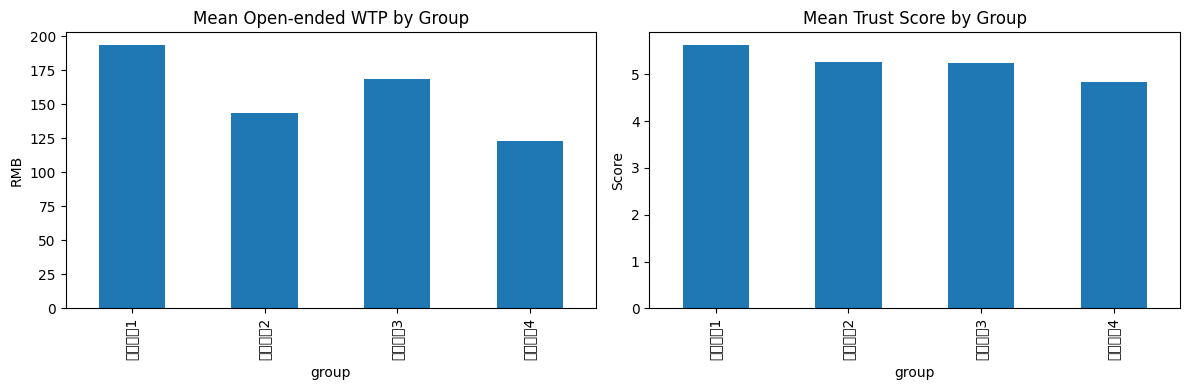

In [4]:
plot_df = df.groupby("group")[["wtp_open", "trust_score"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_df["wtp_open"].plot(kind="bar", ax=axes[0], title="Mean Open-ended WTP by Group")
axes[0].set_ylabel("RMB")

plot_df["trust_score"].plot(kind="bar", ax=axes[1], title="Mean Trust Score by Group")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()


## 4. Hypothesis-oriented tests

In [5]:
# H1: AI vs professional design
ai = df[df["design_source"] == 1]
professional = df[df["design_source"] == 0]

for var in ["wtp_open", "wtp_score", "trust_score"]:
    t_stat, p_val = stats.ttest_ind(ai[var], professional[var], equal_var=False)
    print(f"{var}: AI mean = {ai[var].mean():.2f}, Professional mean = {professional[var].mean():.2f}, t = {t_stat:.3f}, p = {p_val:.4f}")


wtp_open: AI mean = 170.45, Professional mean = 147.54, t = 3.786, p = 0.0002
wtp_score: AI mean = 5.46, Professional mean = 4.86, t = 5.800, p = 0.0000
trust_score: AI mean = 5.45, Professional mean = 5.05, t = 5.180, p = 0.0000


In [6]:
# H2: Trust -> WTP
model_h2 = smf.ols("wtp_open ~ trust_score", data=df).fit()
print(model_h2.summary())


                            OLS Regression Results                            
Dep. Variable:               wtp_open   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     44.25
Date:                Fri, 15 May 2026   Prob (F-statistic):           2.46e-10
Time:                        13:36:29   Log-Likelihood:                -1087.9
No. Observations:                 212   AIC:                             2180.
Df Residuals:                     210   BIC:                             2187.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -7.2851     25.058     -0.291      

In [7]:
# H3a: moderation by AI familiarity
model_h3a = smf.ols("wtp_open ~ design_source * ai_familiarity", data=df).fit()
print(model_h3a.summary())


                            OLS Regression Results                            
Dep. Variable:               wtp_open   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     5.156
Date:                Fri, 15 May 2026   Prob (F-statistic):            0.00185
Time:                        13:36:29   Log-Likelihood:                -1100.6
No. Observations:                 212   AIC:                             2209.
Df Residuals:                     208   BIC:                             2223.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [8]:
# H4: moderation by product added value
model_h4 = smf.ols("wtp_open ~ design_source * added_value", data=df).fit()
print(model_h4.summary())


                            OLS Regression Results                            
Dep. Variable:               wtp_open   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     35.41
Date:                Fri, 15 May 2026   Prob (F-statistic):           1.56e-18
Time:                        13:36:29   Log-Likelihood:                -1064.5
No. Observations:                 212   AIC:                             2137.
Df Residuals:                     208   BIC:                             2150.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

## Interpretation notes
- The descriptive statistics and bar charts show the strongest willingness to pay in **实验情境1 (AI + high added value)** and the weakest in **实验情境4 (professional team + low added value)**.
- The simple AI vs. professional comparison suggests that the AI conditions have higher mean willingness to pay on average.
- Trust is positively associated with willingness to pay in a simple regression.
- The interaction with AI familiarity can be checked in the H3a model.
- The `design_source × added_value` interaction can be checked in the H4 model.

You can use this notebook as the base for later EDA, visualization, and regression sections in the final paper.
